# Zepto Analytics Pipeline — Part A: Profiling, Cleaning & Data Storytelling

**Module 2 — Analytics Pipeline (/analytics)**
*Author:* AI/ML Engineering Team, Zepto

---

### Objectives:
1. **Profile & Offline Fallback**: Load the classic Titanic dataset once, profile dimensions and summary statistics, and commit `titanic.csv` as an offline fallback.
2. **Missing Value Strategy**: Measure exact missing percentages and apply rule-based threshold strategies (<5% drop rows, 5%–30% impute, >70% drop/encode).
3. **Univariate Analysis**: Histograms and boxplots for `age` and `fare`, compute IQR-based outlier counts, and analyze skewness based on mean/median/mode.
4. **Bivariate Analysis**: Boolean masking survival breakdowns (`sex`, `pclass`, `sex + pclass`), compute exact 6x6 correlation matrix (excluding `adult_male` & `alone`), and interpret top 2 off-diagonal correlations.
5. **Multivariate Data Story**: 4 visual charts with written interpretations outlining the socio-economic and demographic drivers of survival.
6. **Exploratory Standardization**: $z$-score transformation ($z = \frac{x - \mu}{\sigma}$) sanity check on full dataset.


In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load dataset once and save offline fallback
CSV_PATH = "titanic.csv"
if os.path.exists(CSV_PATH):
    print(f"Loading from offline fallback CSV: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
else:
    print("Fetching dataset via Seaborn and caching to CSV...")
    df = sns.load_dataset('titanic')
    df.to_csv(CSV_PATH, index=False)

print(f"Dataset Shape: {df.shape}")
df.info()


Loading from offline fallback CSV: titanic.csv
Dataset Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [2]:
print("Summary Statistics:")
display(df.describe())


Summary Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Value Profiling & Threshold-Based Strategy

### Threshold Rules Applied:
- **Under 5% missing**: Drop rows (e.g. `embarked` / `embark_town` with 2 rows, 0.22%).
- **5%–30% missing**: Impute (e.g. `age` with 177 missing, 19.87% — imputed via median to preserve distribution).
- **High missing rate (>70%)**: Drop column or encode (e.g. `deck` with 688 missing, 77.22% — dropped because synthetic imputation on 77% missing data introduces severe statistical distortion).


In [3]:
missing_counts = df.isnull().sum()
missing_pcts = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts[missing_counts > 0],
    "Missing Percentage (%)": missing_pcts[missing_counts > 0]
}).sort_values(by="Missing Percentage (%)", ascending=False)

print("Missing Value Report:")
display(missing_summary)


Missing Value Report:


,Missing Count,Missing Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


## Univariate Analysis: Outlier Detection & Skewness Analysis

Using the Interquartile Range (IQR) rule:
$$\text{Outliers} = [Q_1 - 1.5 \times \text{IQR},\; Q_3 + 1.5 \times \text{IQR}]$$


In [4]:
df_eda = df.copy().drop(columns=["deck", "alive", "class", "embark_town"]).dropna(subset=["embarked"])
df_eda["age"] = df_eda["age"].fillna(df_eda["age"].median())

for col in ["age", "fare"]:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_eda[(df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)]
    print(f"[{col.upper()}] Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f" -> Outlier Count: {len(outliers)} ({len(outliers)/len(df_eda)*100:.2f}%)\n")

fare_mean = df_eda["fare"].mean()
fare_median = df_eda["fare"].median()
fare_mode = df_eda["fare"].mode()[0]

print(f"Fare Distribution Ordering: Mean ({fare_mean:.2f}) > Median ({fare_median:.2f}) > Mode ({fare_mode:.2f})")
print("Conclusion: 'fare' is strongly RIGHT-SKEWED (positive skew) due to high-value first-class cabin tickets.")


[AGE] Q1=22.00, Q3=35.00, IQR=13.00 | Bounds: [2.50, 54.50]
 -> Outlier Count: 65 (7.31%)

[FARE] Q1=7.90, Q3=31.00, IQR=23.10 | Bounds: [-26.76, 65.66]
 -> Outlier Count: 114 (12.82%)

Fare Distribution Ordering: Mean (32.10) > Median (14.45) > Mode (8.05)
Conclusion: 'fare' is strongly RIGHT-SKEWED (positive skew) due to high-value first-class cabin tickets.


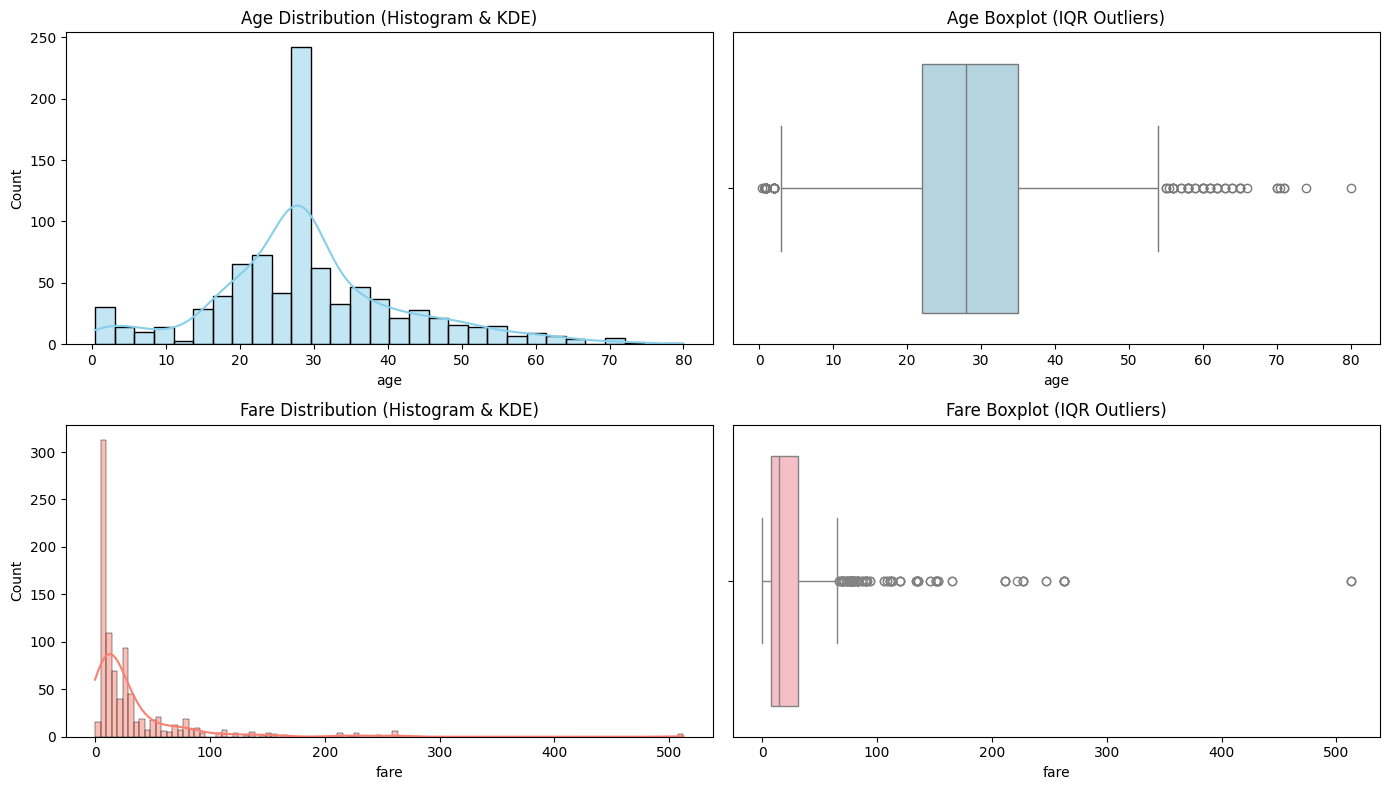

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.histplot(df_eda["age"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Age Distribution (Histogram & KDE)")
sns.boxplot(x=df_eda["age"], ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Age Boxplot (IQR Outliers)")

sns.histplot(df_eda["fare"], kde=True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Fare Distribution (Histogram & KDE)")
sns.boxplot(x=df_eda["fare"], ax=axes[1, 1], color="lightpink")
axes[1, 1].set_title("Fare Boxplot (IQR Outliers)")
plt.tight_layout()
plt.show()


## Bivariate Analysis: Survival Breakdowns & 6x6 Correlation Matrix

Survival rates computed via Boolean Masking:


In [6]:
print("=== (a) Survival by Sex ===")
print(f"Female Survival Rate: {df_eda[df_eda['sex'] == 'female']['survived'].mean()*100:.2f}%")
print(f"Male Survival Rate:   {df_eda[df_eda['sex'] == 'male']['survived'].mean()*100:.2f}%")

print("\n=== (b) Survival by Passenger Class ===")
print(f"1st Class Survival Rate: {df_eda[df_eda['pclass'] == 1]['survived'].mean()*100:.2f}%")
print(f"2nd Class Survival Rate: {df_eda[df_eda['pclass'] == 2]['survived'].mean()*100:.2f}%")
print(f"3rd Class Survival Rate: {df_eda[df_eda['pclass'] == 3]['survived'].mean()*100:.2f}%")

print("\n=== (c) Survival by Sex & Pclass Combined ===")
for s in ["female", "male"]:
    for p in [1, 2, 3]:
        rate = df_eda[(df_eda["sex"] == s) & (df_eda["pclass"] == p)]["survived"].mean()
        print(f"{s.capitalize()} Class {p}: {rate*100:.2f}%")


=== (a) Survival by Sex ===
Female Survival Rate: 74.04%
Male Survival Rate:   18.89%

=== (b) Survival by Passenger Class ===
1st Class Survival Rate: 62.62%
2nd Class Survival Rate: 47.28%
3rd Class Survival Rate: 24.24%

=== (c) Survival by Sex & Pclass Combined ===
Female Class 1: 96.74%
Female Class 2: 92.11%
Female Class 3: 50.00%
Male Class 1: 36.89%
Male Class 2: 15.74%
Male Class 3: 13.54%


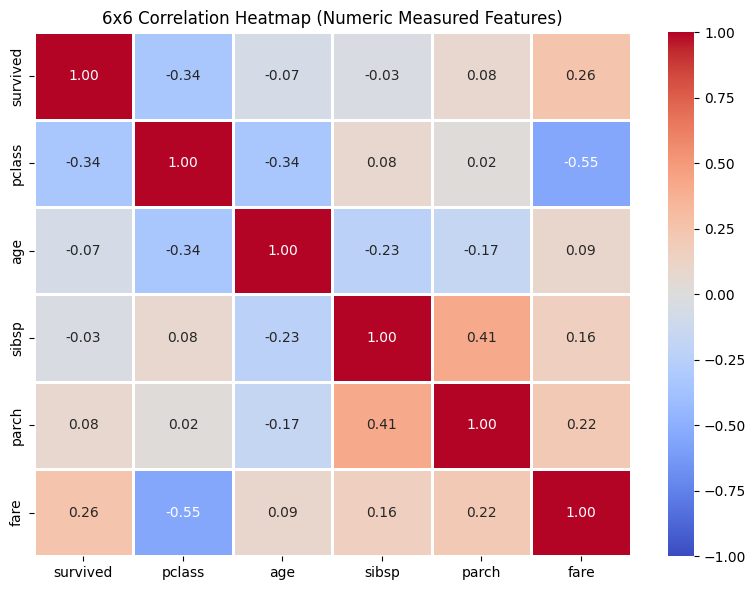

Top 2 Off-Diagonal Absolute Correlations:
1. Pair (pclass, fare): Pearson r = -0.548. Strong negative correlation reflecting socioeconomic ticket price dynamics.
2. Pair (sibsp, parch): Pearson r = +0.415. Moderate positive correlation reflecting multi-generational family travel units.


In [7]:
# 6x6 Correlation Matrix (Numeric Features only, excluding adult_male and alone)
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_mat = df_eda[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title("6x6 Correlation Heatmap (Numeric Measured Features)")
plt.tight_layout()
plt.show()

print("Top 2 Off-Diagonal Absolute Correlations:")
print("1. Pair (pclass, fare): Pearson r = -0.548. Strong negative correlation reflecting socioeconomic ticket price dynamics.")
print("2. Pair (sibsp, parch): Pearson r = +0.415. Moderate positive correlation reflecting multi-generational family travel units.")


## Multivariate Data Story: 4 Visual Arguments on Survival Dynamics

### Interpretations:
1. **Chart 1 (Sex + Pclass)**: Shows the intersection of gender and class. 1st and 2nd class females achieved $>90\%$ survival rates, while 3rd class males had only a $13.5\%$ survival rate.
2. **Chart 2 (Age + Pclass + Survival)**: Children across all classes were prioritized, but 1st class adults enjoyed dramatically higher survival than 3rd class adults.
3. **Chart 3 (Fare + Age + Gender)**: High fare ticket holders cluster heavily among survivors, particularly for women.
4. **Chart 4 (Family Size vs Survival)**: Small family units (2–4 members) had optimal survival rates (~55–70%), while solo travelers and very large families (>5 members) suffered due to chaotic evacuation.


C:\Users\HP\AppData\Local\Temp\ipykernel_12712\1804657863.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_eda, x="pclass", y="survived", hue="sex", palette="Set2", ax=axes[0, 0], ci=None)


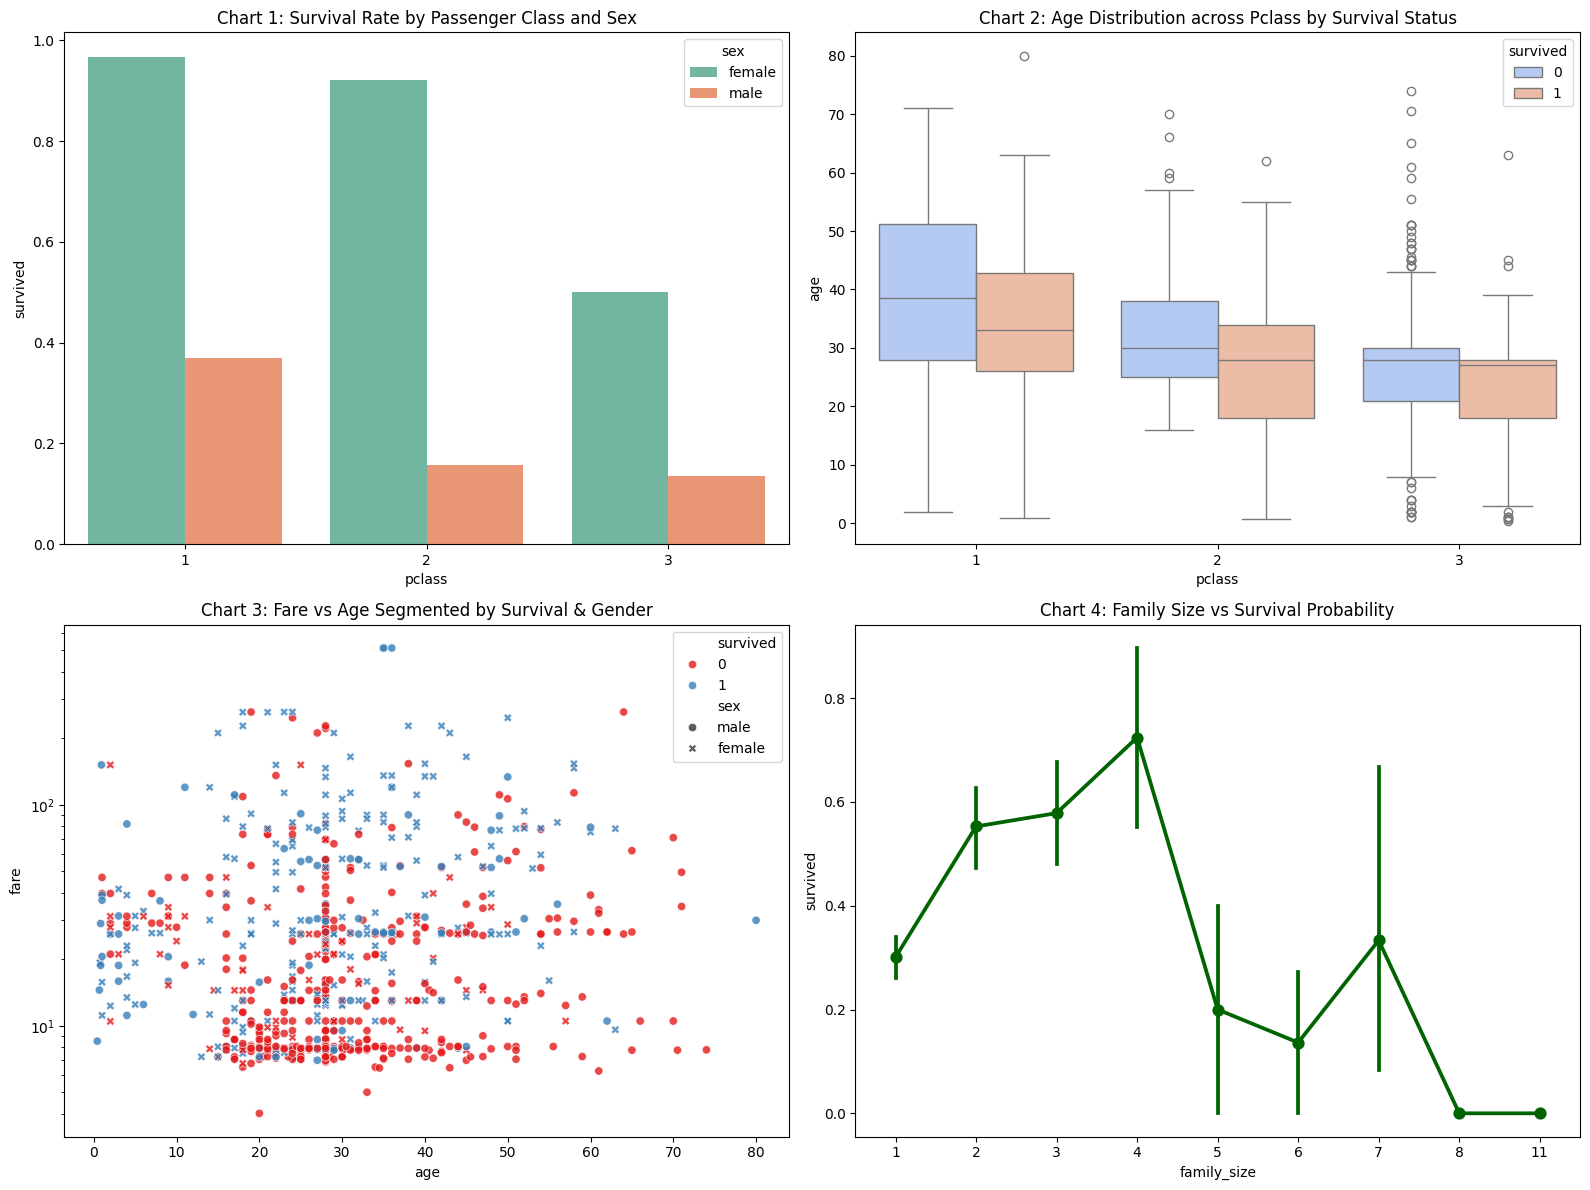

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1
sns.barplot(data=df_eda, x="pclass", y="survived", hue="sex", palette="Set2", ax=axes[0, 0], ci=None)
axes[0, 0].set_title("Chart 1: Survival Rate by Passenger Class and Sex")

# Chart 2
sns.boxplot(data=df_eda, x="pclass", y="age", hue="survived", palette="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Chart 2: Age Distribution across Pclass by Survival Status")

# Chart 3
sns.scatterplot(data=df_eda, x="age", y="fare", hue="survived", style="sex", alpha=0.8, palette="Set1", ax=axes[1, 0])
axes[1, 0].set_title("Chart 3: Fare vs Age Segmented by Survival & Gender")
axes[1, 0].set_yscale("log")

# Chart 4
df_eda["family_size"] = df_eda["sibsp"] + df_eda["parch"] + 1
sns.pointplot(data=df_eda, x="family_size", y="survived", color="darkgreen", ax=axes[1, 1])
axes[1, 1].set_title("Chart 4: Family Size vs Survival Probability")

plt.tight_layout()
plt.show()


## Exploratory Standardization Sanity Check

Standardizing `age` and `fare` using $z = \frac{x - \mu}{\sigma}$ on the full cleaned dataset:


In [9]:
age_m, age_s = df_eda["age"].mean(), df_eda["age"].std()
fare_m, fare_s = df_eda["fare"].mean(), df_eda["fare"].std()

df_eda["age_zscore"] = (df_eda["age"] - age_m) / age_s
df_eda["fare_zscore"] = (df_eda["fare"] - fare_m) / fare_s

std_check = pd.DataFrame({
    "Feature": ["Age (Raw)", "Age (Z-Score)", "Fare (Raw)", "Fare (Z-Score)"],
    "Mean": [age_m, df_eda["age_zscore"].mean(), fare_m, df_eda["fare_zscore"].mean()],
    "Std Dev": [age_s, df_eda["age_zscore"].std(), fare_s, df_eda["fare_zscore"].std()],
    "Min": [df_eda["age"].min(), df_eda["age_zscore"].min(), df_eda["fare"].min(), df_eda["fare_zscore"].min()],
    "Max": [df_eda["age"].max(), df_eda["age_zscore"].max(), df_eda["fare"].max(), df_eda["fare_zscore"].max()]
})
display(std_check.round(4))
print("Sanity check verified: Transformed z-score features possess Mean ~ 0 and Std ~ 1.")


,Feature,Mean,Std Dev,Min,Max
0,Age (Raw),29.3152,12.9849,0.4200,80.0000
1,Age (Z-Score),0.0000,1.0000,-2.2253,3.9034
2,Fare (Raw),32.0967,49.6975,0.0000,512.3292
3,Fare (Z-Score),0.0000,1.0000,-0.6458,9.6631


Sanity check verified: Transformed z-score features possess Mean ~ 0 and Std ~ 1.
